# 🎯 Tarea 5 — Atención con puntero para el WTAP

**Generación de datos de imitación y modelo de atención con puntero** para el *Weapon-Target Assignment Problem*.

En la Tarea 4 entrenamos una **MLP** que imita, paso a paso, a un experto (una Búsqueda Local Iterada) para construir soluciones del WTAP. Funcionó (gap de 4,4 % respecto del experto, mejor que la heurística clásica MMR), pero dejamos anotadas tres limitaciones:

1. **Pesos por posición.** Al aplanar la entrada, el objetivo 3 y el objetivo 7 se procesan con pesos distintos aunque la pregunta ("¿es buen destino para esta arma?") sea la misma.
2. **Tamaño fijo.** La MLP solo sirve para W = 10 armas y T = 8 objetivos.
3. **Orden fijo de armas.** El agente asignaba el arma 0, luego la 1, …, y no podía elegir *qué* arma usar primero (MMR sí puede).

Siguiendo el notebook *"Atención para el TSP: de la MLP al puntero"*, reemplazamos la MLP por un **encoder con self-attention** y una **capa de decisión tipo puntero**, y aprovechamos el cambio para rediseñar la acción:

> **Decisión puntual del modelo:** dado el estado actual (qué armas ya se asignaron y a qué objetivos), **¿qué arma asigno ahora y a qué objetivo?**

Cada acción posible es un **par (arma $i$ → objetivo $j$)** y se representa como **una fila** de la matriz de entrada; el puntero entrega un logit por fila. Es exactamente la pregunta que se hace la heurística constructiva clásica del WTAP, **MMR** (*Maximum Marginal Return*), que en cada paso evalúa la ganancia de *todos* los pares (arma libre, objetivo).

| Sección | Contenido | Paso de la tarea |
|---|---|---|
| 2–3 | Entorno WTAP con acciones por pares, MMR y experto (ILS) | — |
| 4 | Descomposición de soluciones en tuplas (estado, acciones posibles, acción escogida) | 1 |
| 5 | `state2vec`: matriz `(1 + W·T, 16)` | 2 |
| 6 | Salida y generación de datos de entrenamiento, validación y prueba | 3 y 4 |
| 7 | Modelo `WTAP_Attention` y validación sin entrenar | 5 |
| 8 | Entrenamiento *(opcional)* | 7 |
| 9–10 | Agente guiado por el modelo, evaluación y generalización *(opcional)* | 8 |

> ⏱️ El notebook completo tarda unos 50 minutos en una CPU de 4 núcleos (casi todo es entrenamiento). Si en Colab hay GPU (*Entorno de ejecución → Cambiar tipo de entorno*), se usa automáticamente.

## 1. Instalación y librerías

Usamos la librería del curso [`eda`](https://github.com/rilianx/eda) para el `GreedyAgent` y el `SingleAgentSolver` (los mismos del TSP y de la Tarea 4). El entorno del WTAP lo implementamos nosotros en la sección 2 con la misma interfaz que `TSP_Environment`.

In [1]:
!test -d eda || git clone -q https://github.com/rilianx/eda.git

In [2]:
import os, json, time, copy, random, itertools
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from copy import deepcopy
from torch.utils.data import TensorDataset, DataLoader

from eda.agents import SingleAgentSolver, GreedyAgent
from eda.utils import handle_multiple_states

N_WEAPONS = 10   # W de las instancias de ENTRENAMIENTO (luego probaremos con instancias más grandes)
N_TARGETS = 8    # T de las instancias de entrenamiento
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

os.makedirs("figuras_t5", exist_ok=True)
def guardar(fig, nombre):
    fig.savefig(f"figuras_t5/{nombre}.png", dpi=160, bbox_inches="tight")

Dispositivo: cpu


## 2. El problema y el entorno

Tenemos **W armas** y **T objetivos**. El objetivo $j$ tiene un **valor** $V_j$ y el arma $i$ lo destruye con **probabilidad** $p_{ij}$ (disparos independientes; $q_{ij} = 1 - p_{ij}$ es la probabilidad de que sobreviva). Cada arma se asigna como máximo a un objetivo y un objetivo puede recibir varias armas. Se minimiza el **valor esperado que sobrevive**:

$$\min_x \; Z = \sum_{j=1}^{T} V_j \prod_{i=1}^{W} (1 - p_{ij})^{x_{ij}}$$

Llamamos $q_j = \prod_i (1-p_{ij})^{x_{ij}}$ a la **probabilidad de que el objetivo $j$ sobreviva** con las armas asignadas hasta ahora. Como en la Tarea 4, las instancias siguen la literatura (Ahuja et al., 2007): $V_j \sim U\{25,\dots,100\}$ y $p_{ij} \sim U(0{,}6;\ 0{,}9)$. Entrenamos con **W = 10, T = 8**, pero el modelo aceptará cualquier tamaño.

### Acciones constructivas por pares
- **Estado inicial:** ninguna arma asignada (`assignment = [-1, …, -1]`).
- **Acción** `("constructive", (i, j))`: asignar el **arma libre** $i$ al objetivo $j$. Con $k$ armas libres hay $k \cdot T$ acciones posibles (80 al inicio).
- Para el experto mantenemos los movimientos de **búsqueda local** de la Tarea 4 sobre soluciones completas: `("reassign", (i, j))` y `("swap", (i, k))`.

In [3]:
class WTAP_Instance:
    def __init__(self, values, probs):
        self.values = np.asarray(values, dtype=float)   # V_j,  forma (T,)
        self.probs  = np.asarray(probs,  dtype=float)   # p_ij, forma (W, T)
        self.n_weapons, self.n_targets = self.probs.shape

    @staticmethod
    def random(n_weapons=N_WEAPONS, n_targets=N_TARGETS, rng=np.random):
        values = rng.randint(25, 101, size=n_targets).astype(float)
        probs  = rng.uniform(0.6, 0.9, size=(n_weapons, n_targets))
        return WTAP_Instance(values, probs)


class WTAP_State:
    # assignment[i] = objetivo asignado al arma i (-1 si el arma i aún está libre)
    def __init__(self, inst_info, assignment=None):
        self.inst_info = inst_info
        self.assignment = list(assignment) if assignment is not None else [-1] * inst_info.n_weapons
        self.update_cost()

    def update_cost(self):
        # q_j = prob. de que el objetivo j sobreviva; costo = valor esperado que sobrevive
        P = self.inst_info.probs
        self.q = np.ones(self.inst_info.n_targets)
        for i, j in enumerate(self.assignment):
            if j >= 0:
                self.q[j] *= 1 - P[i, j]
        self.cost = float(self.inst_info.values @ self.q)
        return self.cost

    @property
    def free_weapons(self):
        return [i for i, j in enumerate(self.assignment) if j < 0]

    @property
    def is_complete(self):
        return all(j >= 0 for j in self.assignment)

    def __deepcopy__(self, memo):
        return type(self)(self.inst_info, list(self.assignment))

    def __str__(self):
        return (f"Asignación (arma -> objetivo): {self.assignment}\n"
                f"Valor esperado que sobrevive: {self.cost:.3f}")


class WTAP_Environment:
    @staticmethod
    def gen_actions(state, type, shuffle=False):
        inst = state.inst_info
        if type == "constructive":     # todos los pares (arma libre, objetivo)
            actions = [("constructive", (i, j)) for i in state.free_weapons for j in range(inst.n_targets)]
        elif type == "reassign":
            actions = [("reassign", (i, j)) for i in range(inst.n_weapons)
                       for j in range(inst.n_targets) if j != state.assignment[i]]
        elif type == "swap":
            a = state.assignment
            actions = [("swap", (i, k)) for i in range(inst.n_weapons)
                       for k in range(i + 1, inst.n_weapons) if a[i] != a[k]]
        else:
            raise NotImplementedError(f"Tipo de acción '{type}' no implementado")
        if shuffle:
            random.shuffle(actions)
        for action in actions:
            yield action

    @staticmethod
    def state_transition(state, action):
        P, V = state.inst_info.probs, state.inst_info.values
        kind, arg = action
        if kind == "constructive" and state.assignment[arg[0]] < 0:   # asignar el arma libre i al objetivo j
            i, j = arg
            state.assignment[i] = j
            state.q[j] *= 1 - P[i, j]
        elif kind == "reassign" and state.is_complete:                 # mover el arma i al objetivo j
            i, j = arg
            a = state.assignment[i]
            state.q[a] /= 1 - P[i, a]
            state.q[j] *= 1 - P[i, j]
            state.assignment[i] = j
        elif kind == "swap" and state.is_complete:                     # intercambiar objetivos de i y k
            i, k = arg
            a, b = state.assignment[i], state.assignment[k]
            state.q[a] *= (1 - P[k, a]) / (1 - P[i, a])
            state.q[b] *= (1 - P[i, b]) / (1 - P[k, b])
            state.assignment[i], state.assignment[k] = b, a
        else:
            raise NotImplementedError(f"Movimiento '{action}' no válido para el estado {state}")
        state.cost = float(V @ state.q)
        return state

    @staticmethod
    def calculate_cost_after_action(state, action):
        return WTAP_Environment.state_transition(deepcopy(state), action).cost


def cost_of(inst, assignment):
    # costo de una asignación (parcial o completa), calculado directamente con la fórmula
    P = inst.probs
    q = np.ones(inst.n_targets)
    for i, j in enumerate(assignment):
        if j >= 0:
            q[j] *= 1 - P[i, j]
    return float(inst.values @ q)

env = WTAP_Environment   # reglas del juego: acciones y transiciones

**Sanity check del entorno:** construimos una solución aleatoria par a par y luego aplicamos movimientos de búsqueda local; en cada paso el costo actualizado incrementalmente debe coincidir con el recalculado desde cero.

In [4]:
random.seed(0)
rng = np.random.RandomState(123)
inst = WTAP_Instance.random(rng=rng)
state = WTAP_State(inst)
print("Costo de la solución vacía (suma de valores):", state.cost)
print("Acciones constructivas posibles al inicio:", len(list(env.gen_actions(state, "constructive"))), "= W·T")

while not state.is_complete:
    action = random.choice(list(env.gen_actions(state, "constructive")))
    env.state_transition(state, action)
    assert abs(state.cost - cost_of(inst, state.assignment)) < 1e-9
print(state)

for _ in range(200):
    kind = random.choice(["reassign", "swap"])
    env.state_transition(state, random.choice(list(env.gen_actions(state, kind))))
    assert abs(state.cost - cost_of(inst, state.assignment)) < 1e-9
print("✔ construcción par a par + 200 movimientos de búsqueda local: costo incremental == costo recalculado")

Costo de la solución vacía (suma de valores): 563.0
Acciones constructivas posibles al inicio: 80 = W·T
Asignación (arma -> objetivo): [5, 5, 1, 0, 7, 7, 1, 5, 0, 1]
Valor esperado que sobrevive: 332.037
✔ construcción par a par + 200 movimientos de búsqueda local: costo incremental == costo recalculado


## 3. La heurística clásica (MMR) y el experto (ILS)

### MMR: el "vecino más cercano" del WTAP
Asignar el arma $i$ al objetivo $j$ reduce el costo en la **ganancia marginal**

$$g_{ij} = V_j \, q_j \, p_{ij}$$

(el valor que aún está en juego en $j$ por la probabilidad de destruirlo). **MMR** (den Broeder et al., 1959) elige en cada paso el par (arma libre, objetivo) de **mayor ganancia**. Con acciones por pares, MMR es simplemente el `GreedyAgent` de `eda` con `evalConstructiveActions` = ganancia marginal, igual que el vecino más cercano en el TSP. Esa ganancia es, por lo tanto, la característica clave que debe ver el modelo (sección 5).

In [5]:
@handle_multiple_states
def evalConstructiveActions(state, env):
    # MMR: ganancia marginal V_j * q_j * p_ij de cada par (arma libre i, objetivo j)
    V, P = state.inst_info.values, state.inst_info.probs
    evals = []
    for action in env.gen_actions(state, "constructive"):
        i, j = action[1]
        evals.append((action, V[j] * state.q[j] * P[i, j]))
    return evals


def mmr(inst):
    # Maximum Marginal Return, versión directa (sin agente) para usar dentro del experto
    V, P = inst.values, inst.probs
    q = np.ones(inst.n_targets)
    assignment = [-1] * inst.n_weapons
    free = list(range(inst.n_weapons))
    while free:
        gains = (V * q)[None, :] * P[free]                 # (armas libres, T)
        r, j = np.unravel_index(np.argmax(gains), gains.shape)
        i = free.pop(r)
        assignment[i] = int(j)
        q[j] *= 1 - P[i, j]
    return assignment


mmr_agent = SingleAgentSolver(env, GreedyAgent(evalConstructiveActions))
rng = np.random.RandomState(5)
for _ in range(20):
    inst = WTAP_Instance.random(rng=rng)
    sol, *_ = mmr_agent.solve(WTAP_State(inst))
    assert sol.assignment == mmr(inst)
print("✔ GreedyAgent(evalConstructiveActions) reproduce exactamente a MMR en 20 instancias")

np.random.seed(7)
inst_demo = WTAP_Instance.random()          # misma instancia de ejemplo de la Tarea 4
sol_mmr, *_ = mmr_agent.solve(WTAP_State(inst_demo))
print("\nMMR en la instancia de ejemplo:\n", sol_mmr)

✔ GreedyAgent(evalConstructiveActions) reproduce exactamente a MMR en 20 instancias

MMR en la instancia de ejemplo:
 Asignación (arma -> objetivo): [4, 1, 2, 3, 7, 3, 6, 5, 0, 1]
Valor esperado que sobrevive: 57.081


### El experto: Búsqueda Local Iterada (la misma de la Tarea 4)
1. **Solución inicial:** MMR.
2. **Búsqueda local (best improvement)** con los vecindarios `reassign` y `swap`, con deltas de costo vectorizados en `numpy`.
3. **Perturbación:** reasigna aleatoriamente 3 armas y vuelve a la búsqueda local.
4. **Aceptación:** si mejora (o con probabilidad 5 %); guarda siempre la mejor solución.

En la Tarea 4 verificamos con un método exacto (*meet-in-the-middle*) que el ILS alcanza el **óptimo** en 10/10 instancias de 10×8; aquí repetimos la verificación en 3 instancias.

In [6]:
def q_of(P, a, T):
    q = np.ones(T)
    np.multiply.at(q, a, 1 - P[np.arange(len(a)), a])
    return q


def local_search(V, P, a, q):
    # best improvement con vecindarios reassign + swap (deltas vectorizados)
    W, T = P.shape
    idx = np.arange(W)
    while True:
        pa = P[idx, a]
        removal = V[a] * q[a] * pa / (1 - pa)                   # aumento de costo al quitar el arma i
        delta_re = removal[:, None] - (V * q)[None, :] * P      # (W, T)
        delta_re[idx, a] = np.inf
        term = (V[a] * q[a])[:, None] * ((1 - P[:, a].T) / (1 - pa)[:, None] - 1)
        delta_sw = term + term.T                                # (W, W)
        delta_sw[a[:, None] == a[None, :]] = np.inf
        best_re, best_sw = delta_re.min(), delta_sw.min()
        if min(best_re, best_sw) > -1e-9:                       # óptimo local
            return a, q
        if best_re <= best_sw:
            i, j = np.unravel_index(np.argmin(delta_re), delta_re.shape)
            q[a[i]] /= 1 - P[i, a[i]]; q[j] *= 1 - P[i, j]; a[i] = j
        else:
            i, k = np.unravel_index(np.argmin(delta_sw), delta_sw.shape)
            ai, ak = a[i], a[k]
            q[ai] *= (1 - P[k, ai]) / (1 - P[i, ai])
            q[ak] *= (1 - P[i, ak]) / (1 - P[k, ak])
            a[i], a[k] = ak, ai


def ils(inst, n_iter=100, k_perturb=3, rng=None):
    rng = rng or np.random.default_rng()
    V, P = inst.values, inst.probs
    W, T = P.shape
    a = np.array(mmr(inst))                                      # 1. inicio: MMR
    a, q = local_search(V, P, a, q_of(P, a, T))                  # 2. búsqueda local
    cur_cost = V @ q
    best_a, best_cost = a.copy(), cur_cost
    for _ in range(n_iter):
        b = a.copy()
        ws = rng.choice(W, size=k_perturb, replace=False)        # 3. perturbación
        b[ws] = rng.integers(0, T, size=k_perturb)
        b, qb = local_search(V, P, b, q_of(P, b, T))
        cb = V @ qb
        if cb < cur_cost - 1e-12 or rng.random() < 0.05:         # 4. aceptación
            a, cur_cost = b, cb
        if cb < best_cost - 1e-12:
            best_a, best_cost = b.copy(), cb
    return [int(x) for x in best_a], cost_of(inst, best_a)


sol_ils, cost_ils = ils(inst_demo, rng=np.random.default_rng(0))
print(f"Experto (ILS) en la instancia de ejemplo: {sol_ils}  costo = {cost_ils:.3f}  (MMR: {sol_mmr.cost:.3f})")

Experto (ILS) en la instancia de ejemplo: [3, 7, 2, 5, 3, 1, 6, 4, 0, 5]  costo = 52.949  (MMR: 57.081)


In [7]:
def exact_mitm(inst, chunk=512):
    # óptimo exacto por meet-in-the-middle: enumera 8^5 asignaciones de cada mitad de las armas
    V, P = inst.values, inst.probs
    W, T = P.shape
    def enum(ws):
        combos = np.array(list(itertools.product(range(T), repeat=len(ws))))
        q = np.ones((len(combos), T))
        for c, w in enumerate(ws):
            np.multiply.at(q, (np.arange(len(combos)), combos[:, c]), 1 - P[w, combos[:, c]])
        return combos, q
    cA, qA = enum(range(W // 2))
    cB, qB = enum(range(W // 2, W))
    qAV, qBt = qA * V, qB.T
    best, bi, bk = np.inf, -1, -1
    for s in range(0, len(qAV), chunk):
        M = qAV[s:s + chunk] @ qBt
        r, c = np.unravel_index(np.argmin(M), M.shape)
        if M[r, c] < best:
            best, bi, bk = M[r, c], s + r, c
    return [int(x) for x in list(cA[bi]) + list(cB[bk])], float(best)


rng = np.random.RandomState(999)
for k in range(3):
    inst = WTAP_Instance.random(rng=rng)
    _, c_opt = exact_mitm(inst)
    _, c_ils = ils(inst, rng=np.random.default_rng(k))
    print(f"instancia {k}: óptimo = {c_opt:7.3f} | ILS = {c_ils:7.3f} | MMR = {cost_of(inst, mmr(inst)):7.3f}")

instancia 0: óptimo =  42.664 | ILS =  42.664 | MMR =  45.063


instancia 1: óptimo =  29.910 | ILS =  29.910 | MMR =  30.952


instancia 2: óptimo =  42.630 | ILS =  42.630 | MMR =  42.630


## 4. Paso 1 — Descomposición de las soluciones en decisiones

Usamos **acciones constructivas** (agregar un par arma→objetivo a la solución parcial), igual que en el TSP. No usamos movimientos de búsqueda local porque el experto llega a su solución final tras cientos de movimientos `reassign`/`swap` ligados a perturbaciones aleatorias: esa trayectoria no es una política reproducible desde el estado. Una construcción, en cambio, tiene exactamente **W decisiones** y cada una depende solo del estado parcial.

La solución del experto es un **conjunto** de W pares $(i, a^*_i)$ sin orden. Para convertirla en una secuencia necesitamos una regla de orden. Usamos la del propio MMR:

> En cada paso, entre las armas que aún están libres, se toma el par del experto $(i, a^*_i)$ con **mayor ganancia marginal** $V_{a^*_i}\, q_{a^*_i}\, p_{i a^*_i}$ en el estado actual.

- **Estado inicial:** asignación vacía (todas las armas libres), el análogo de `visited=[0]`.
- **Acciones posibles:** todos los pares (arma libre, objetivo): $k \cdot T$ con $k$ armas libres.
- **Acción escogida:** el par del experto que indica la regla anterior. Se aplica `env.state_transition` y se repite.
- **Término:** cuando las W armas están asignadas. A diferencia del TSP no cortamos antes, porque incluso la última arma tiene T destinos posibles y esa decisión no es trivial.

La regla es determinista (una sola etiqueta por estado), sigue siendo **la solución exacta del experto** (cualquier orden reconstruye el mismo conjunto de pares) y es coherente con MMR: las decisiones "obvias" (grandes ganancias) van primero y el modelo puede leerse como *"MMR corregido por el experto"*.

In [8]:
def decompose(inst, expert_assignment):
    """Reproduce la solución del experto como tuplas (estado, acciones posibles, acción escogida).
    Orden: en cada paso, entre las armas libres, el par del experto con mayor ganancia marginal."""
    V, P, a = inst.values, inst.probs, expert_assignment
    state = WTAP_State(inst)                                      # estado inicial: nada asignado
    while not state.is_complete:                                  # término: todas las armas asignadas
        free = state.free_weapons
        gains = [V[a[i]] * state.q[a[i]] * P[i, a[i]] for i in free]
        i = free[int(np.argmax(gains))]
        chosen = ("constructive", (i, a[i]))
        yield deepcopy(state), list(env.gen_actions(state, "constructive")), chosen
        env.state_transition(state, chosen)


print(f"Solución del experto para la instancia de ejemplo: {sol_ils}\n")
print(f"{'paso':>4} | {'armas libres':>12} | {'acciones posibles':>17} | {'acción escogida':>16} | "
      f"{'ganancia':>8} | {'MMR elegiría':>12}")
print("-" * 88)
demo_steps = list(decompose(inst_demo, sol_ils))
for k, (st, actions, chosen) in enumerate(demo_steps):
    evals = evalConstructiveActions(st, env)
    best = max(evals, key=lambda e: e[1])[0][1]
    g = dict(evals)[chosen]
    print(f"{k:>4} | {len(st.free_weapons):>12} | {len(actions):>17} | "
          f"{'arma %d -> obj %d' % chosen[1]:>16} | {g:>8.2f} | {'arma %d -> obj %d' % best:>12}"
          + ("" if best == chosen[1] else "  ≠"))

Solución del experto para la instancia de ejemplo: [3, 7, 2, 5, 3, 1, 6, 4, 0, 5]

paso | armas libres | acciones posibles |  acción escogida | ganancia | MMR elegiría
----------------------------------------------------------------------------------------
   0 |           10 |                80 |  arma 5 -> obj 1 |    81.09 | arma 1 -> obj 1  ≠
   1 |            9 |                72 |  arma 3 -> obj 5 |    69.81 | arma 6 -> obj 3  ≠
   2 |            8 |                64 |  arma 0 -> obj 3 |    69.00 | arma 6 -> obj 3  ≠
   3 |            7 |                56 |  arma 8 -> obj 0 |    61.38 | arma 8 -> obj 0
   4 |            6 |                48 |  arma 2 -> obj 2 |    43.64 | arma 2 -> obj 2
   5 |            5 |                40 |  arma 7 -> obj 4 |    42.70 | arma 7 -> obj 4
   6 |            4 |                32 |  arma 1 -> obj 7 |    42.48 | arma 1 -> obj 7
   7 |            3 |                24 |  arma 6 -> obj 6 |    34.58 | arma 6 -> obj 6
   8 |            2 |         

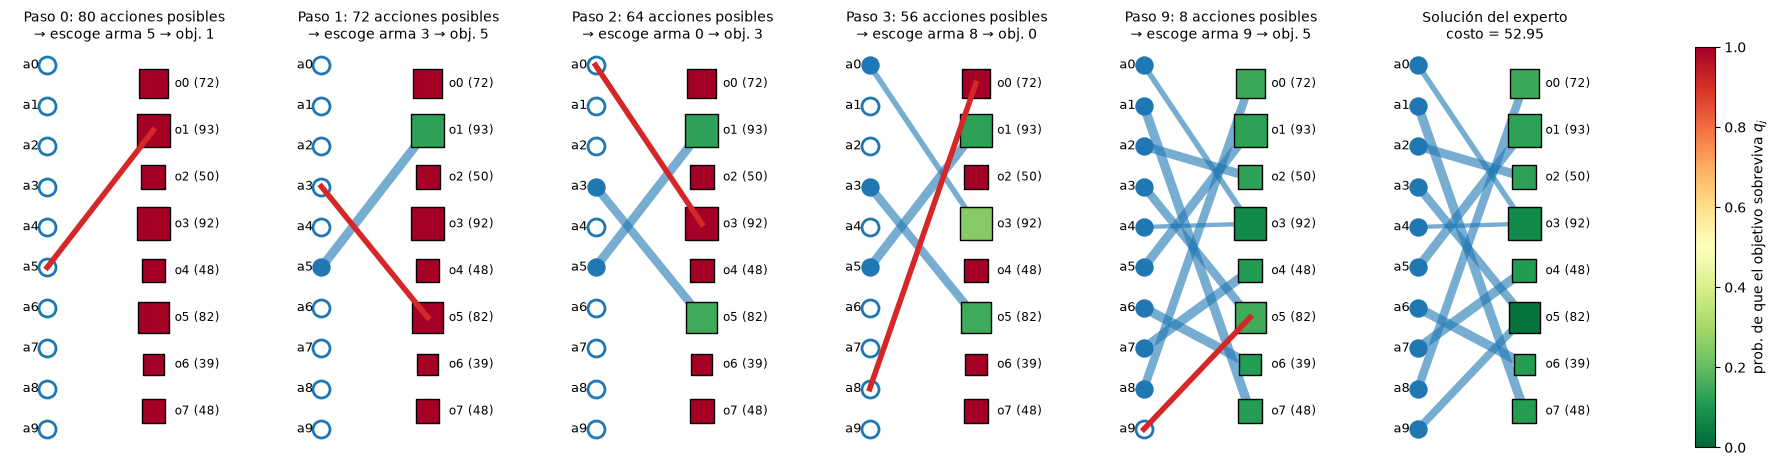

In [9]:
def plot_partial(inst, assignment, chosen=None, title="", ax=None, labels=True):
    # grafo bipartito armas (izq.) -> objetivos (der.). Azul: pares ya asignados; rojo: acción escogida.
    # Tamaño del objetivo ~ valor V_j; color ~ prob. de sobrevivir q_j. Círculo vacío = arma libre.
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.2, 5))
    W, T = inst.n_weapons, inst.n_targets
    q = np.ones(T)
    for i, j in enumerate(assignment):
        if j >= 0:
            q[j] *= 1 - inst.probs[i, j]
    yw, yt = np.linspace(1, 0, W), np.linspace(0.95, 0.05, T)
    for i, j in enumerate(assignment):
        if j >= 0:
            ax.plot([0, 1], [yw[i], yt[j]], color="tab:blue", alpha=0.6,
                    lw=1 + 6 * (inst.probs[i, j] - 0.6) / 0.3, zorder=1)
    if chosen is not None:
        i, j = chosen
        ax.plot([0, 1], [yw[i], yt[j]], color="tab:red", lw=4, zorder=3)
    used = np.array([j >= 0 for j in assignment])
    ax.scatter(np.zeros(W)[used], yw[used], s=150, c="tab:blue", zorder=2)
    ax.scatter(np.zeros(W)[~used], yw[~used], s=150, facecolors="white", edgecolors="tab:blue", lw=2, zorder=2)
    sc = ax.scatter(np.ones(T), yt, s=inst.values * 6, c=q, cmap="RdYlGn_r", vmin=0, vmax=1,
                    marker="s", edgecolors="k", zorder=2)
    if labels:
        for i in range(W): ax.text(-0.08, yw[i], f"a{i}", ha="right", va="center", fontsize=9)
        for j in range(T): ax.text(1.2, yt[j], f"o{j} ({inst.values[j]:.0f})", ha="left", va="center", fontsize=8.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-0.35, 1.8); ax.set_ylim(-0.05, 1.05); ax.axis("off")
    return sc


show = [0, 1, 2, 3, len(demo_steps) - 1]
fig, axes = plt.subplots(1, len(show) + 1, figsize=(22, 5.2))
for ax, k in zip(axes, show):
    st, actions, chosen = demo_steps[k]
    plot_partial(inst_demo, st.assignment, chosen[1], ax=ax,
                 title=f"Paso {k}: {len(actions)} acciones posibles\n→ escoge arma {chosen[1][0]} → obj. {chosen[1][1]}")
sc = plot_partial(inst_demo, sol_ils, ax=axes[-1], title=f"Solución del experto\ncosto = {cost_ils:.2f}")
fig.colorbar(sc, ax=axes, fraction=0.012, label="prob. de que el objetivo sobreviva $q_j$")
guardar(fig, "descomposicion"); plt.show()

## 5. Paso 2 — Codificación de la entrada (`state2vec`)

Como en el notebook del TSP, la entrada **no se aplana**: es una matriz de forma `(n, VEC_LEN)` con `n = 1 + W·T` y `VEC_LEN = 16`.

- **Fila 0 — fila global** (tipo `[CLS]`): resume el estado completo. El modelo la identifica por el flag `es_global` (y además está siempre en la posición 0, como la ciudad inicial del TSP). Nunca es una acción válida.
- **Fila $1 + i \cdot T + j$ — par (arma $i$ → objetivo $j$)**: describe a la vez el estado y la acción "asignar el arma $i$ al objetivo $j$". La fila de un par es siempre la misma durante el episodio.

| # | Columna | Rol | Contenido | ¿Por qué ayuda a decidir? |
|---|---|---|---|---|
| 0 | `p_ij` | propia | $p_{ij}$ | efectividad del arma contra el objetivo |
| 1 | `valor` | propia | $V_j / \max V$ | importancia del objetivo |
| 2 | `p_vs_mejor` | propia | $p_{ij} - \max_{j'} p_{ij'}$ | ¿es $j$ el mejor destino posible para el arma $i$? (≤ 0) |
| 3 | `es_global` | **flag (query)** | 1 solo en la fila 0 | marca la fila que construye la query de decisión |
| 4 | `no_disponible` | **flag (máscara)** | 1 si el arma $i$ ya fue asignada, o si es la fila global | esas filas reciben logit $-10^9$ |
| 5 | `asignado` | flag | 1 si $x_{ij} = 1$ en la solución parcial | contexto: qué pares ya se eligieron |
| 6 | `q_sobrevive` | relativa | $q_j$ | cuánto queda por destruir en $j$ |
| 7 | `valor_en_juego` | relativa | $V_j q_j / \max V$ (fila global: $\sum V q / \sum V$) | valor que aún se puede ganar en $j$ |
| 8 | `ganancia` ⭐ | relativa | $g_{ij} / \max g$ sobre pares disponibles | **criterio de MMR** (el análogo de `dist_a_actual` del TSP) |
| 9 | `es_mmr` | relativa | 1 si es el par que elegiría MMR | la elección de la heurística clásica |
| 10 | `armas_en_obj` | relativa | nº de armas ya asignadas a $j$ / W | rendimientos decrecientes |
| 11 | `ventaja` | relativa | $p_{ij}$ − media de $p_{i'j}$ de las armas libres | ¿es esta arma comparativamente buena para $j$? |
| 12 | `arrepentimiento` | relativa | $(g_{ij} - \max_{i' \neq i \text{ libre}} g_{i'j}) / \max g$ | ¿otra arma libre aprovecharía mejor a $j$? |
| 13 | `mmr_completa` ⭐ | relativa | 1 si al completar con MMR desde este estado el arma $i$ va a $j$ | anticipación: mira las decisiones futuras |
| 14 | `q_final_mmr` | relativa | $q_j$ al completar con MMR | ¿quedará $j$ bien cubierto al final? |
| 15 | `frac_restantes` | global | armas libres / W (repetida en todas las filas) | etapa de la construcción |

Las características relativas se calculan solo para pares **disponibles** (armas libres); en las filas enmascaradas valen 0. Todas están normalizadas **por instancia** (divididas por el máximo o expresadas como fracción), así que su escala no depende de W ni de T y ningún peso del modelo depende del índice de la fila. La información de "qué arma es mejor para qué objetivo" también puede cruzarse entre filas vía self-attention: el par $(i, j)$ puede mirar a los pares $(i', j)$ de las otras armas.

In [10]:
FEATURES = ["p_ij", "valor", "p_vs_mejor", "es_global", "no_disponible", "asignado",
            "q_sobrevive", "valor_en_juego", "ganancia", "es_mmr", "armas_en_obj", "ventaja",
            "arrepentimiento", "mmr_completa", "q_final_mmr", "frac_restantes"]
VEC_LEN = len(FEATURES)                     # 16
COL_GLOBAL = FEATURES.index("es_global")    # 3: fila que forma la query de decisión
COL_MASK = FEATURES.index("no_disponible")  # 4: filas que no son acciones válidas
ROLE = ["propia"] * 3 + ["flag"] * 3 + ["relativa"] * 10


def mmr_completion(V, P, q, free):
    # completa la solución con MMR desde el estado actual: {arma libre: objetivo} y q final
    q = q.copy(); free = list(free); target = {}
    while free:
        gains = (V * q)[None, :] * P[free]
        r, j = np.unravel_index(np.argmax(gains), gains.shape)
        i = free.pop(r); q[j] *= 1 - P[i, j]; target[i] = int(j)
    return target, q


def state2vec(state):
    """Codifica un estado del WTAP como una matriz (1 + W·T, 16).
    Fila 0 = fila global; fila 1 + i·T + j = par (arma i -> objetivo j)."""
    inst = state.inst_info
    V, P = inst.values, inst.probs
    W, T = P.shape
    a = np.asarray(state.assignment)
    q, vmax = state.q, V.max()
    free = a < 0
    fw, done = np.flatnonzero(free), np.flatnonzero(~free)      # armas libres / ya asignadas
    F = np.zeros((W, T, VEC_LEN))

    # 1) características propias del par
    F[:, :, 0] = P
    F[:, :, 1] = V[None, :] / vmax
    F[:, :, 2] = P - P.max(1, keepdims=True)
    # 2) flags de estado
    F[:, :, 4] = (~free)[:, None]                               # máscara: el arma ya no está disponible
    F[done, a[done], 5] = 1                                     # pares de la solución parcial
    # 3) características relativas al estado
    F[:, :, 6] = q[None, :]
    F[:, :, 7] = (V * q / vmax)[None, :]
    F[:, :, 10] = (np.bincount(a[done], minlength=T) / W)[None, :]
    F[:, :, 15] = len(fw) / W
    if len(fw):
        gain = (V * q)[None, :] * P[fw]                         # ganancia de MMR, (armas libres, T)
        gmax = gain.max()
        F[fw, :, 8] = gain / gmax
        r, j = np.unravel_index(np.argmax(gain), gain.shape)
        F[fw[r], j, 9] = 1
        F[fw, :, 11] = P[fw] - P[fw].mean(0, keepdims=True)
        if len(fw) > 1:                                         # mejor ganancia de OTRA arma libre en j
            srt = np.sort(gain, axis=0)
            other = np.where(gain >= srt[-1][None, :], srt[-2][None, :], srt[-1][None, :])
        else:
            other = np.zeros_like(gain)
        F[fw, :, 12] = (gain - other) / gmax
        target, q_mmr = mmr_completion(V, P, q, fw)             # anticipación: completar con MMR
        for i, j in target.items():
            F[i, j, 13] = 1
        F[:, :, 14] = q_mmr[None, :]

    g = np.zeros(VEC_LEN)                                       # fila global
    g[COL_GLOBAL], g[COL_MASK] = 1, 1
    g[7] = V @ q / V.sum()
    g[15] = len(fw) / W
    return np.concatenate([g[None, :], F.reshape(W * T, VEC_LEN)]).astype(np.float32)

Veámoslo en el **paso 4** de la descomposición de la instancia de ejemplo (4 armas ya asignadas). Primero algunas filas; luego la matriz completa como mapa de calor (transpuesta: cada columna del gráfico es una fila de la matriz).

In [11]:
K_DEMO = 4
st_demo, actions_demo, chosen_demo = demo_steps[K_DEMO]
x_demo = state2vec(st_demo)
row_demo = 1 + chosen_demo[1][0] * N_TARGETS + chosen_demo[1][1]
print("Estado:", st_demo.assignment, "| forma de state2vec:", x_demo.shape)
print(f"El experto escoge arma {chosen_demo[1][0]} -> objetivo {chosen_demo[1][1]}  (fila {row_demo})\n")

def row_name(r, T=N_TARGETS):
    return "global" if r == 0 else f"a{(r - 1) // T}->o{(r - 1) % T}"

cols = [0, 3, 4, 5, 8, 9, 11, 12, 13, 15]
top = [0] + list(np.argsort(-x_demo[:, 8])[:6])
if row_demo not in top: top.append(row_demo)
print(f"{'fila':>12} | " + " ".join(f"{FEATURES[c][:10]:>10}" for c in cols))
print("-" * 125)
for r in top:
    mark = "  <- experto" if r == row_demo else ""
    print(f"{row_name(r):>12} | " + " ".join(f"{x_demo[r, c]:>10.2f}" for c in cols) + mark)

Estado: [3, -1, -1, 5, -1, 1, -1, -1, 0, -1] | forma de state2vec: (81, 16)
El experto escoge arma 2 -> objetivo 2  (fila 19)

        fila |       p_ij  es_global no_disponi   asignado   ganancia     es_mmr    ventaja arrepentim mmr_comple frac_resta
-----------------------------------------------------------------------------------------------------------------------------
      global |       0.00       1.00       1.00       0.00       0.00       0.00       0.00       0.00       0.00       0.60
      a2->o2 |       0.87       0.00       0.00       0.00       1.00       1.00       0.15       0.11       1.00       0.60  <- experto
      a7->o4 |       0.89       0.00       0.00       0.00       0.98       0.00       0.09       0.01       1.00       0.60
      a1->o7 |       0.89       0.00       0.00       0.00       0.97       0.00       0.09       0.08       1.00       0.60
      a1->o4 |       0.88       0.00       0.00       0.00       0.97       0.00       0.08      -0.01       0

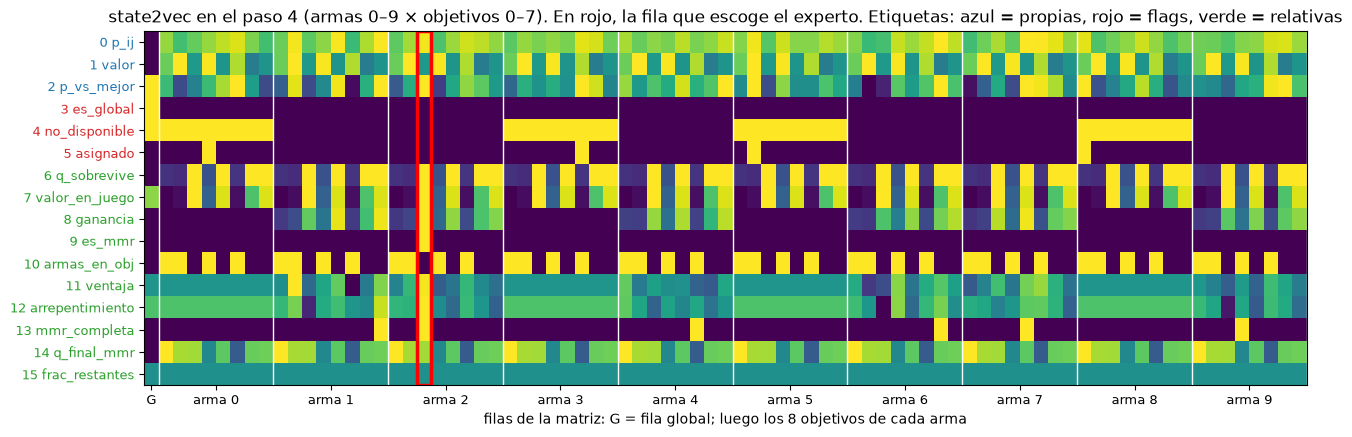

In [12]:
def plot_state_matrix(x, chosen_row, W, T, title=""):
    # muestra la matriz transpuesta; cada característica normalizada a [0, 1] solo para visualizar
    lo, hi = x.min(0), x.max(0)
    xs = np.where(hi > lo, (x - lo) / np.where(hi > lo, hi - lo, 1), 0.5)   # columnas constantes: color medio
    fig, ax = plt.subplots(figsize=(15, 4.6))
    ax.imshow(xs.T, cmap="viridis", aspect="auto", interpolation="nearest")
    for i in range(W + 1):
        ax.axvline(0.5 + i * T, color="white", lw=1)
    ax.set_xticks([0] + [1 + i * T + (T - 1) / 2 for i in range(W)])
    ax.set_xticklabels(["G"] + [f"arma {i}" for i in range(W)], fontsize=9)
    ax.set_yticks(range(VEC_LEN)); ax.set_yticklabels([f"{k:>2} {f}" for k, f in enumerate(FEATURES)], fontsize=9)
    colors = {"propia": "tab:blue", "flag": "tab:red", "relativa": "tab:green"}
    for lbl, role in zip(ax.get_yticklabels(), ROLE):
        lbl.set_color(colors[role])
    ax.add_patch(plt.Rectangle((chosen_row - 0.5, -0.5), 1, VEC_LEN, fill=False, ec="red", lw=2.5))
    ax.set_xlabel("filas de la matriz: G = fila global; luego los 8 objetivos de cada arma")
    ax.set_title(title)
    return fig

fig = plot_state_matrix(x_demo, row_demo, N_WEAPONS, N_TARGETS,
                        f"state2vec en el paso {K_DEMO} (armas 0–9 × objetivos 0–7). En rojo, la fila que escoge el experto. "
                        "Etiquetas: azul = propias, rojo = flags, verde = relativas")
guardar(fig, "estado"); plt.show()

## 6. Pasos 3 y 4 — Codificación de la salida y generación de datos

### Salida (paso 3)
El modelo entrega un **vector de logits de largo $n = 1 + W\cdot T$**, uno por fila; tras un softmax es la probabilidad de que cada fila sea la próxima acción.

- **Acción ↔ fila:** la acción `("constructive", (i, j))` es "elegir la fila $1 + i\cdot T + j$". Como cada fila ya es un par, no hace falta combinar dos elementos como en un 2-opt: el puntero selecciona el par directamente.
- **Máscara:** las filas con `no_disponible = 1` (columna 4) reciben logit $-10^9$ y probabilidad 0: la fila global y los T pares de cada arma ya asignada. Con $k$ armas libres quedan exactamente $k \cdot T$ filas válidas, las mismas acciones que genera `env.gen_actions`.
- **Etiqueta `Y`:** el índice (entero) de la fila escogida por el experto. Equivale a un vector one-hot de largo $n$, pero se guarda como entero para `CrossEntropyLoss`.

### Generación de datos (paso 4)
`generate_imitation_data` genera instancias aleatorias, las resuelve con el experto (ILS), descompone cada solución con `decompose` y transforma cada tupla en un par `(x, y) = (state2vec(estado), fila escogida)`. Además retorna las instancias resueltas para reutilizar el costo del experto en la evaluación.

- **Entrenamiento:** 6 000 instancias 10×8 (semilla 0) → 60 000 muestras.
- **Validación:** 300 instancias (semilla 1) → 3 000 muestras (early stopping y selección de configuración).
- **Prueba:** 50 instancias (semilla 2024), **las mismas de la Tarea 4**, para comparar directamente con la MLP.

In [13]:
def action2row(action, n_targets):
    i, j = action[1]
    return 1 + i * n_targets + j

def row2action(row, n_targets):
    return ("constructive", ((row - 1) // n_targets, (row - 1) % n_targets))


def solve_instances(n_weapons, n_targets, n_instances, seed):
    # genera instancias aleatorias y las resuelve con el experto (ILS)
    rng, rng_ils = np.random.RandomState(seed), np.random.default_rng(seed)
    solved = []
    for _ in range(n_instances):
        inst = WTAP_Instance.random(n_weapons, n_targets, rng=rng)
        expert_assignment, expert_cost = ils(inst, rng=rng_ils)
        solved.append((inst, expert_assignment, expert_cost))
    return solved


def generate_imitation_data(n_weapons=N_WEAPONS, n_targets=N_TARGETS, n_instances=100, seed=0):
    solved = solve_instances(n_weapons, n_targets, n_instances, seed)       # 1-2. instancias + experto
    X, Y = [], []
    for inst, expert_assignment, _ in solved:
        for state, actions, chosen in decompose(inst, expert_assignment):  # 3. tuplas paso a paso
            X.append(state2vec(state))                                     # 4. x = state2vec(estado)
            Y.append(action2row(chosen, n_targets))                        #    y = fila escogida
    return torch.tensor(np.stack(X)), torch.tensor(Y, dtype=torch.long), solved


t0 = time.time()
X_train, Y_train, train_solved = generate_imitation_data(N_WEAPONS, N_TARGETS, n_instances=6000, seed=0)
X_val,   Y_val,   val_solved   = generate_imitation_data(N_WEAPONS, N_TARGETS, n_instances=300,  seed=1)
X_test,  Y_test,  test_solved  = generate_imitation_data(N_WEAPONS, N_TARGETS, n_instances=50,   seed=2024)
print(f"Datos generados en {time.time() - t0:.0f} s\n")
print("X_train:", tuple(X_train.shape), "-> (muestras, 1 + W·T filas, VEC_LEN)")
print("Y_train:", tuple(Y_train.shape), "-> fila escogida por el experto")
print("X_val:  ", tuple(X_val.shape), "| Y_val:", tuple(Y_val.shape))
print("X_test: ", tuple(X_test.shape), "| Y_test:", tuple(Y_test.shape))
test_expert = np.array([c for _, _, c in test_solved])
print(f"\nCosto medio del experto en las 50 instancias de prueba: {test_expert.mean():.3f} (Tarea 4: 46.263)")

Datos generados en 105 s

X_train: (60000, 81, 16) -> (muestras, 1 + W·T filas, VEC_LEN)
Y_train: (60000,) -> fila escogida por el experto
X_val:   (3000, 81, 16) | Y_val: (3000,)
X_test:  (500, 81, 16) | Y_test: (500,)

Costo medio del experto en las 50 instancias de prueba: 46.263 (Tarea 4: 46.263)


**Sanity check.** Mostramos la matriz `state2vec` completa de una muestra, su fila escogida y verificamos que **no** esté enmascarada. Luego comprobamos lo mismo en *todas* las muestras, además de que haya exactamente una fila global por estado y que el número de filas válidas sea (armas libres)·T.

In [14]:
k = 4                                    # quinta decisión de la primera instancia de entrenamiento
x, y = X_train[k].numpy(), Y_train[k].item()
print("Columnas:", ", ".join(f"{c}={f}" for c, f in enumerate(FEATURES)), "\n")
print(f"{'fila':>4} {'':>8} " + " ".join(f"{c:>5}" for c in range(VEC_LEN)))
for r in range(x.shape[0]):
    print(f"{r:>4} {row_name(r):>8} " + " ".join(f"{v:>5.2f}" for v in x[r]) + ("   <-- fila escogida" if r == y else ""))
print(f"\nFila escogida: {y} = {row2action(y, N_TARGETS)} | no_disponible = {x[y, COL_MASK]:.0f}")
assert x[y, COL_MASK] == 0

for name, X, Y in [("train", X_train, Y_train), ("val", X_val, Y_val), ("test", X_test, Y_test)]:
    assert (X[torch.arange(len(Y)), Y, COL_MASK] == 0).all()             # la fila escogida nunca está enmascarada
    assert ((X[:, :, COL_GLOBAL] == 1).sum(1) == 1).all()                # una fila global por estado
    free = X[:, 0, 15] * N_WEAPONS                                       # frac_restantes · W
    assert torch.allclose((X[:, :, COL_MASK] == 0).sum(1).float(), free * N_TARGETS)
print("✔ En train/val/test: la fila escogida nunca está enmascarada, hay una fila global por estado "
      "y las filas válidas son (armas libres)·T")

Columnas: 0=p_ij, 1=valor, 2=p_vs_mejor, 3=es_global, 4=no_disponible, 5=asignado, 6=q_sobrevive, 7=valor_en_juego, 8=ganancia, 9=es_mmr, 10=armas_en_obj, 11=ventaja, 12=arrepentimiento, 13=mmr_completa, 14=q_final_mmr, 15=frac_restantes 

fila              0     1     2     3     4     5     6     7     8     9    10    11    12    13    14    15
   0   global  0.00  0.00  0.00  1.00  1.00  0.00  0.00  0.46  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.60
   1   a0->o0  0.69  0.75 -0.16  0.00  1.00  0.00  1.00  0.75  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.60
   2   a0->o1  0.62  0.78 -0.23  0.00  1.00  0.00  0.10  0.08  0.00  0.00  0.10  0.00  0.00  0.00  0.10  0.60
   3   a0->o2  0.68  0.97 -0.17  0.00  1.00  0.00  0.14  0.13  0.00  0.00  0.10  0.00  0.00  0.00  0.03  0.60
   4   a0->o3  0.74  1.00 -0.11  0.00  1.00  0.00  0.11  0.11  0.00  0.00  0.10  0.00  0.00  0.00  0.11  0.60
   5   a0->o4  0.84  1.00 -0.01  0.00  1.00  1.00  0.16  0.16  0.00  0.00  0.10  0.00  0.00  0.00  0

## 7. Paso 5 — El modelo `WTAP_Attention`

La estructura es la de `TSP_Attention`: **embedding compartido → self-attention con residual → feed-forward → query de decisión → puntero con máscara**. Lo que cambia:

| | `TSP_Attention` | `WTAP_Attention` |
|---|---|---|
| Filas de la entrada | ciudades | fila global + pares (arma, objetivo) |
| `VEC_LEN` | 6 | 16 |
| Encoder | 1 bloque, sin normalización | 2 bloques con **LayerNorm** y **Dropout** (el correo advierte que al imitar trayectorias exactas el modelo se sobreajusta fácilmente) |
| **Query de decisión** (paso 3) | $q = W_c[h_{\text{actual}} ; h_{\text{inicial}}]$ con `es_actual` (col. 2) y la fila 0 | $q = W_c[h_{\text{global}} ; \bar h_{\text{disp}}]$: la fila marcada con `es_global` (col. 3) y el **promedio de las filas disponibles** |
| **Máscara** (paso 4) | `visitada` (col. 3) | `no_disponible` (col. 4) |
| Puntero | $u_i = (W_Q^{ptr} q)\cdot(W_K^{ptr} h_i)/\sqrt d$ | igual |

En el WTAP no hay una "ciudad actual": el estado es la solución parcial completa. Por eso la query se arma con la **fila global**, que tras la self-attention resume todo el estado (como el token `[CLS]` de BERT), y con el **promedio de los pares aún disponibles** (el "embedding del grafo" de Kool et al., 2019, que el notebook del TSP sugiere como extensión). Mantenemos el tamaño moderado: $d = 64$ y 2 capas.

In [15]:
class EncoderBlock(nn.Module):
    # self-attention + feed-forward, ambos con conexión residual, LayerNorm y Dropout
    def __init__(self, d, dropout):
        super().__init__()
        self.d = d
        self.Wq = nn.Linear(d, d, bias=False)
        self.Wk = nn.Linear(d, d, bias=False)
        self.Wv = nn.Linear(d, d, bias=False)
        self.ff = nn.Sequential(nn.Linear(d, 2 * d), nn.ReLU(), nn.Linear(2 * d, d))
        self.norm1, self.norm2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.drop = nn.Dropout(dropout)

    def forward(self, H):
        Q, K, V = self.Wq(H), self.Wk(H), self.Wv(H)
        A = torch.softmax(Q @ K.transpose(1, 2) / self.d ** 0.5, dim=-1)   # (batch, n, n)
        H = self.norm1(H + self.drop(A @ V))                                # residual
        H = self.norm2(H + self.drop(self.ff(H)))                           # residual
        return H


class WTAP_Attention(nn.Module):
    def __init__(self, vec_len=VEC_LEN, d=64, n_layers=2, dropout=0.1):
        super().__init__()
        self.d = d
        # --- Encoder ---
        self.embed   = nn.Linear(vec_len, d)                               # embedding por fila (pesos compartidos)
        self.encoder = nn.ModuleList([EncoderBlock(d, dropout) for _ in range(n_layers)])
        # --- Decisión ---
        self.Wc     = nn.Linear(2 * d, d)                                  # [h_global ; promedio disponibles] -> q
        self.Wq_ptr = nn.Linear(d, d, bias=False)                          # proyecciones del puntero
        self.Wk_ptr = nn.Linear(d, d, bias=False)

    def forward(self, x, return_probabilities=False):
        # x tiene forma (batch, 1 + W·T, VEC_LEN) -- W y T pueden ser cualesquiera
        if x.dim() == 2:
            x = x.unsqueeze(0)

        # 1. Embedding por fila (mismos pesos para todos los pares)
        H = self.embed(x)                                                   # (batch, n, d)

        # 2. Self-attention: cada par mira a todos los demás (2 bloques)
        for block in self.encoder:
            H = block(H)

        # 3. Query de decisión: fila global + promedio de los pares disponibles
        h_global = H[x[:, :, COL_GLOBAL] == 1]                              # el flag marca una fila por estado
        disp = (x[:, :, COL_MASK] == 0).float().unsqueeze(-1)               # (batch, n, 1)
        h_disp = (H * disp).sum(1) / disp.sum(1).clamp(min=1)
        q = self.Wc(torch.cat([h_global, h_disp], dim=-1))                  # (batch, d)

        # 4. Puntero: compatibilidad de q con cada fila -> un logit por fila
        u = (self.Wk_ptr(H) @ self.Wq_ptr(q).unsqueeze(-1)).squeeze(-1)     # (batch, n)
        u = u / self.d ** 0.5
        u = u.masked_fill(x[:, :, COL_MASK] == 1, -1e9)                     # máscara: filas no disponibles

        if return_probabilities:
            return torch.softmax(u, dim=-1)
        return u


torch.manual_seed(0)
model = WTAP_Attention()
print(model)
print("\nParámetros entrenables:", sum(p.numel() for p in model.parameters() if p.requires_grad))

WTAP_Attention(
  (embed): Linear(in_features=16, out_features=64, bias=True)
  (encoder): ModuleList(
    (0-1): 2 x EncoderBlock(
      (Wq): Linear(in_features=64, out_features=64, bias=False)
      (Wk): Linear(in_features=64, out_features=64, bias=False)
      (Wv): Linear(in_features=64, out_features=64, bias=False)
      (ff): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=64, bias=True)
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (drop): Dropout(p=0.1, inplace=False)
    )
  )
  (Wc): Linear(in_features=128, out_features=64, bias=True)
  (Wq_ptr): Linear(in_features=64, out_features=64, bias=False)
  (Wk_ptr): Linear(in_features=64, out_features=64, bias=False)
)

Parámetros entrenables: 75776


**Validación del modelo (sin entrenar).** Verificamos, como en el notebook del TSP:
1. la salida tiene forma `(batch, n)` y cada fila suma 1;
2. las filas enmascaradas tienen probabilidad 0;
3. la query se construye con exactamente **una** fila global por estado;
4. el mismo modelo acepta, sin modificaciones, un estado de una instancia de **otro tamaño** (20 armas × 15 objetivos → 301 filas);
5. la `CrossEntropyLoss` se calcula sin errores sobre un mini-lote. Sin entrenar, las probabilidades son casi uniformes sobre las acciones válidas, así que la pérdida debe rondar $\overline{\log(\#\text{válidas})}$.

In [16]:
model.eval()
xb, yb = X_train[:16], Y_train[:16]
with torch.no_grad():
    probs = model(xb, return_probabilities=True)
print("1. Forma de la salida:", tuple(probs.shape), "-> (batch, 1 + W·T)")
print("   Suma de probabilidades por estado:", probs.sum(-1).numpy().round(4))
assert probs.shape == (16, 1 + N_WEAPONS * N_TARGETS) and torch.allclose(probs.sum(-1), torch.ones(16))

p_masked = probs[xb[:, :, COL_MASK] == 1].max().item()
print("2. Prob. máxima en filas enmascaradas (debe ser 0):", p_masked)
assert p_masked == 0

n_global = (xb[:, :, COL_GLOBAL] == 1).sum(1)
print("3. Filas globales por estado (debe ser 1):", n_global.tolist())
assert (n_global == 1).all()
with torch.no_grad():
    H = model.embed(xb)
    for block in model.encoder:
        H = block(H)
    print("   h_global:", tuple(H[xb[:, :, COL_GLOBAL] == 1].shape), "-> un vector de dimensión d por estado")

rng = np.random.RandomState(5)
inst20 = WTAP_Instance.random(20, 15, rng=rng)
state20 = WTAP_State(inst20)
for _ in range(3):                                   # 3 armas asignadas con MMR
    evals = evalConstructiveActions(state20, env)
    env.state_transition(state20, max(evals, key=lambda e: e[1])[0])
x20 = torch.tensor(state2vec(state20))
with torch.no_grad():
    probs20 = model(x20, return_probabilities=True)
print(f"4. Instancia 20×15: entrada {tuple(x20.shape)} -> salida {tuple(probs20.shape)}, "
      f"suma = {probs20.sum().item():.4f}, filas válidas con prob > 0: {(probs20 > 0).sum().item()} "
      f"(= 17 armas libres × 15)  -> ¡ningún peso depende de W ni de T!")
assert (probs20 > 0).sum().item() == 17 * 15

loss = nn.CrossEntropyLoss()(model(xb), yb)
ref = torch.log((xb[:, :, COL_MASK] == 0).sum(1).float()).mean()
print(f"5. CrossEntropyLoss sobre el mini-lote: {loss.item():.3f}  (referencia uniforme: {ref.item():.3f})")

1. Forma de la salida: (16, 81) -> (batch, 1 + W·T)
   Suma de probabilidades por estado: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
2. Prob. máxima en filas enmascaradas (debe ser 0): 0.0
3. Filas globales por estado (debe ser 1): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
   h_global: (16, 64) -> un vector de dimensión d por estado
4. Instancia 20×15: entrada (301, 16) -> salida (1, 301), suma = 1.0000, filas válidas con prob > 0: 255 (= 17 armas libres × 15)  -> ¡ningún peso depende de W ni de T!
5. CrossEntropyLoss sobre el mini-lote: 3.731  (referencia uniforme: 3.769)


## 8. (Opcional) Paso 7 — Entrenamiento

El ciclo es el del notebook: entropía cruzada, Adam, mini-lotes y **early stopping** sobre la pérdida de validación (se restauran los pesos de la mejor época). Lo escribimos como función para comparar configuraciones.

> *"Un accuracy alto no garantiza buenos rollouts"*: como en la Tarea 4, elegimos la configuración por el **gap del rollout** en 100 instancias de validación (no de prueba).

In [17]:
def train_model(X_train, Y_train, X_val, Y_val, d=64, n_layers=2, dropout=0.1, batch_size=256, lr=1e-3,
                num_epochs=100, patience=8, min_delta=1e-3, seed=0, verbose=True):
    torch.manual_seed(seed)
    model = WTAP_Attention(vec_len=X_train.shape[2], d=d, n_layers=n_layers, dropout=dropout).to(device)
    loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    Xv, Yv = X_val.to(device), Y_val.to(device)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss, best_weights, best_epoch, epochs_no_improve = float("inf"), None, 0, 0
    for epoch in range(num_epochs):
        model.train()
        train_loss, train_hits = 0.0, 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()                  # 1. borrar gradientes
            logits = model(xb)                     # 2. forward
            loss = criterion(logits, yb)           # 3. pérdida
            loss.backward()                        # 4. backward
            optimizer.step()                       # 5. actualizar pesos
            train_loss += loss.item() * xb.size(0)
            train_hits += (logits.argmax(-1) == yb).sum().item()
        train_loss /= len(loader.dataset); train_acc = train_hits / len(loader.dataset)

        model.eval()
        with torch.no_grad():
            val_logits = torch.cat([model(Xv[s:s + 1024]) for s in range(0, len(Xv), 1024)])
            val_loss = criterion(val_logits, Yv).item()
            val_acc = (val_logits.argmax(-1) == Yv).float().mean().item()
        for key, value in zip(history, [train_loss, val_loss, train_acc, val_acc]):
            history[key].append(value)
        if verbose and epoch % 5 == 0:
            print(f"Época {epoch:3d} | loss train: {train_loss:.3f} | loss val: {val_loss:.3f} "
                  f"| acc train: {train_acc:.3f} | acc val: {val_acc:.3f}")

        if val_loss < best_val_loss - min_delta:
            best_val_loss, best_epoch, epochs_no_improve = val_loss, epoch, 0
            best_weights = copy.deepcopy(model.state_dict())
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"⏹ Early stopping en época {epoch}. Mejor época: {best_epoch} "
                          f"| loss val: {best_val_loss:.3f} | acc val: {history['val_acc'][best_epoch]:.3f}")
                break
    model.load_state_dict(best_weights)
    history["best_epoch"] = best_epoch
    return model.cpu(), history

Para medir el gap del rollout necesitamos el agente, que se define en detalle en la sección 9. `ModelEvalActions` es el del notebook del TSP, pero indexa las probabilidades con la fila del par: `predictions[k][1 + i·T + j]`.

In [18]:
class ModelEvalActions():
    def __init__(self, model):
        self.model = model

    def __call__(self, states, env):
        single_state = not isinstance(states, list)
        if single_state:
            states = [states]
        pending = [k for k, s in enumerate(states) if not s.is_complete]
        evals = [[] for _ in states]
        if pending:
            vecs = np.stack([state2vec(states[k]) for k in pending])     # mismo tamaño dentro de un lote
            self.model.eval()
            with torch.no_grad():
                predictions = self.model(torch.tensor(vecs), return_probabilities=True)
            for row, k in enumerate(pending):
                T = states[k].inst_info.n_targets
                evals[k] = [(action, predictions[row][action2row(action, T)].item())
                            for action in env.gen_actions(states[k], "constructive")]
        return evals[0] if single_state else evals


def rollout_costs(eval_actions, instances):
    # construye soluciones completas para muchas instancias en paralelo con el agente greedy
    solver = SingleAgentSolver(env, GreedyAgent(eval_actions))
    final_states, *_ = solver.multistate_solve([WTAP_State(inst) for inst in instances])
    assert all(s.is_complete for s in final_states)
    return np.array([s.cost for s in final_states])


def gap(costs, expert_costs):
    return 100 * (np.asarray(costs) / np.asarray(expert_costs) - 1)


val_insts = [inst for inst, _, _ in val_solved[:100]]
val_expert = np.array([c for _, _, c in val_solved[:100]])
gap_mmr_val = gap(rollout_costs(evalConstructiveActions, val_insts), val_expert).mean()
print(f"Referencia en 100 instancias de validación -> MMR: gap = {gap_mmr_val:.2f}%")

Referencia en 100 instancias de validación -> MMR: gap = 6.94%


### Experimentos: Dropout y tamaño
El correo advierte que, al imitar trayectorias exactas, el modelo tiende a sobreajustarse. Mantenemos una arquitectura moderada (d = 64, 2 capas, ~76 mil parámetros) y comparamos tres niveles de **Dropout** (0; 0,1; 0,2). Para cada uno medimos el accuracy de validación y el gap del rollout en 100 instancias de validación, y elegimos por el gap.

In [19]:
configs = [
    # nombre,                                  hiperparámetros de train_model
    ("A · d=64, 2 capas, sin Dropout",       dict(d=64, n_layers=2, dropout=0.0)),
    ("B · d=64, 2 capas, Dropout 0.1",       dict(d=64, n_layers=2, dropout=0.1)),
    ("C · d=64, 2 capas, Dropout 0.2",       dict(d=64, n_layers=2, dropout=0.2)),
]

experiments = {}
for name, cfg in configs:
    t0 = time.time()
    print(f"--- {name} ---")
    m, h = train_model(X_train, Y_train, X_val, Y_val, **cfg)
    costs = rollout_costs(ModelEvalActions(m), val_insts)
    experiments[name] = {"model": m, "history": h, "config": cfg,
                         "val_acc": h["val_acc"][h["best_epoch"]], "val_loss": h["val_loss"][h["best_epoch"]],
                         "gap": gap(costs, val_expert).mean(),
                         "params": sum(p.numel() for p in m.parameters())}
    print(f"==> acc val = {experiments[name]['val_acc']:.3f} | gap rollout val = {experiments[name]['gap']:.2f}% "
          f"| épocas = {len(h['val_loss'])} | {time.time() - t0:.0f} s\n")

print(f"{'Configuración':<34} {'parámetros':>10} {'acc val':>8} {'loss val':>9} {'gap val':>8}")
for name, e in experiments.items():
    print(f"{name:<34} {e['params']:>10} {e['val_acc']:>8.3f} {e['val_loss']:>9.3f} {e['gap']:>7.2f}%")
print(f"{'MMR (referencia)':<34} {'':>10} {'':>8} {'':>9} {gap_mmr_val:>7.2f}%")

--- A · d=64, 2 capas, sin Dropout ---


Época   0 | loss train: 0.621 | loss val: 0.468 | acc train: 0.802 | acc val: 0.823


Época   5 | loss train: 0.397 | loss val: 0.398 | acc train: 0.847 | acc val: 0.844


Época  10 | loss train: 0.368 | loss val: 0.360 | acc train: 0.855 | acc val: 0.856


Época  15 | loss train: 0.356 | loss val: 0.367 | acc train: 0.858 | acc val: 0.855


...

Época  10 | loss train: 0.372 | loss val: 0.359 | acc train: 0.851 | acc val: 0.850


Época  15 | loss train: 0.361 | loss val: 0.339 | acc train: 0.856 | acc val: 0.861


Época  20 | loss train: 0.354 | loss val: 0.337 | acc train: 0.859 | acc val: 0.865


⏹ Early stopping en época 22. Mejor época: 14 | loss val: 0.335 | acc val: 0.862


==> acc val = 0.862 | gap rollout val = 3.90% | épocas = 23 | 658 s

Configuración                      parámetros  acc val  loss val  gap val
A · d=64, 2 capas, sin Dropout          75776    0.873     0.313    3.35%
B · d=64, 2 capas, Dropout 0.1          75776    0.872     0.320    3.51%
C · d=64, 2 capas, Dropout 0.2          75776    0.862     0.335    3.90%
MMR (referencia)                                                    6.94%


Modelo elegido (menor gap en validación): A · d=64, 2 capas, sin Dropout


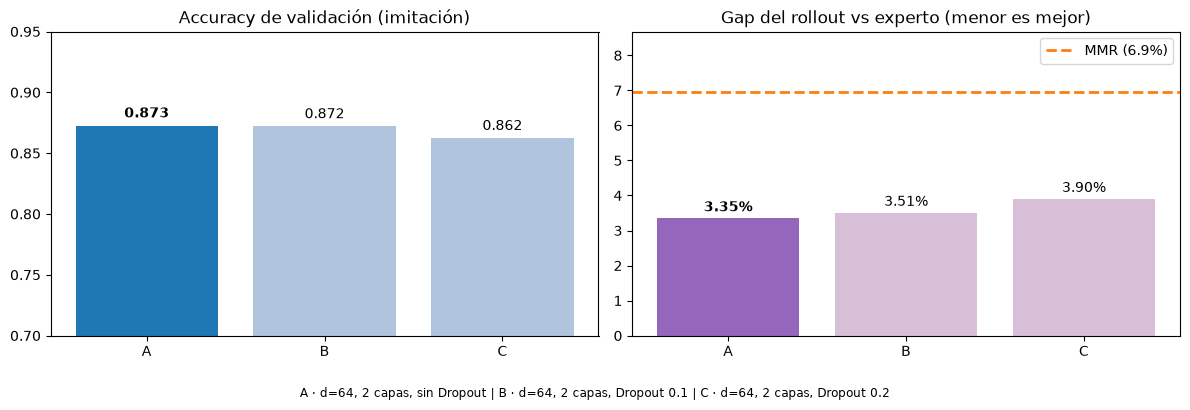

In [20]:
best_name = min(experiments, key=lambda n: experiments[n]["gap"])
best = experiments[best_name]
model, history = best["model"], best["history"]
print("Modelo elegido (menor gap en validación):", best_name)

names = list(experiments)
short = [n.split(" · ")[0] for n in names]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
accs = [experiments[n]["val_acc"] for n in names]
gaps = [experiments[n]["gap"] for n in names]
axes[0].bar(short, accs, color=["tab:blue" if n == best_name else "lightsteelblue" for n in names])
axes[0].set_ylim(0.7, 0.95); axes[0].set_title("Accuracy de validación (imitación)")
axes[1].bar(short, gaps, color=["tab:purple" if n == best_name else "thistle" for n in names])
axes[1].axhline(gap_mmr_val, color="tab:orange", ls="--", lw=2, label=f"MMR ({gap_mmr_val:.1f}%)")
axes[1].set_title("Gap del rollout vs experto (menor es mejor)"); axes[1].legend(loc="upper right")
axes[1].set_ylim(0, max(gaps + [gap_mmr_val]) * 1.25)
for ax, vals, fmt, off in [(axes[0], accs, "{:.3f}", 0.004), (axes[1], gaps, "{:.2f}%", 0.1)]:
    for i, v in enumerate(vals):
        ax.text(i, v + off, fmt.format(v), ha="center", va="bottom", fontsize=10,
                fontweight="bold" if names[i] == best_name else "normal")
fig.text(0.5, -0.06, " | ".join(names), ha="center", fontsize=8.5)
plt.tight_layout(); guardar(fig, "experimentos"); plt.show()

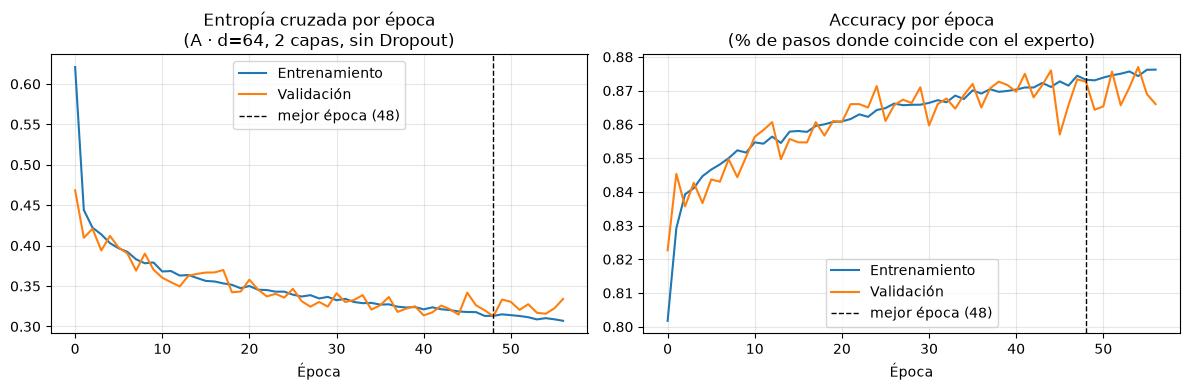

In [21]:
def plot_history(history, title_suffix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ep = np.arange(len(history["train_loss"])); b = history["best_epoch"]
    axes[0].plot(ep, history["train_loss"], label="Entrenamiento")
    axes[0].plot(ep, history["val_loss"], label="Validación")
    axes[0].set_title("Entropía cruzada por época" + title_suffix); axes[0].set_xlabel("Época")
    axes[1].plot(ep, history["train_acc"], label="Entrenamiento")
    axes[1].plot(ep, history["val_acc"], label="Validación")
    axes[1].set_title("Accuracy por época\n(% de pasos donde coincide con el experto)"); axes[1].set_xlabel("Época")
    for ax in axes:
        ax.axvline(b, color="k", ls="--", lw=1, label=f"mejor época ({b})")
        ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout()
    return fig

fig = plot_history(history, f"\n({best_name})"); guardar(fig, "curvas"); plt.show()

### Accuracy por paso de la construcción
¿En qué decisiones se equivoca más el modelo? Separamos el accuracy de validación por paso (paso 0 = primera asignación, con 80 acciones posibles; paso 9 = última, con 8).

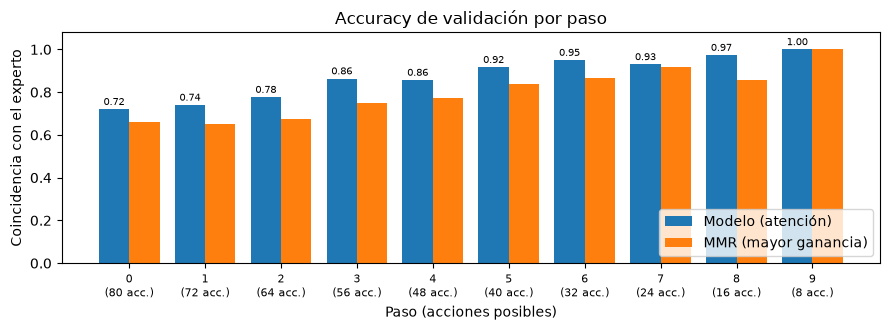

Accuracy global -> modelo: 0.873 | MMR: 0.799


In [22]:
model.eval()
with torch.no_grad():
    pred_val = torch.cat([model(X_val[s:s + 1024]).argmax(-1) for s in range(0, len(X_val), 1024)]).numpy()
acc_step = (pred_val == Y_val.numpy()).reshape(-1, N_WEAPONS).mean(0)
mmr_pick = np.argmax(np.where(X_val[:, :, COL_MASK].numpy() == 1, -1, X_val[:, :, 8].numpy()), 1)
acc_mmr_step = (mmr_pick == Y_val.numpy()).reshape(-1, N_WEAPONS).mean(0)

fig, ax = plt.subplots(figsize=(9, 3.4))
xs = np.arange(N_WEAPONS)
ax.bar(xs - 0.2, acc_step, 0.4, color="tab:blue", label="Modelo (atención)")
ax.bar(xs + 0.2, acc_mmr_step, 0.4, color="tab:orange", label="MMR (mayor ganancia)")
ax.set_xticks(xs); ax.set_xticklabels([f"{k}\n({(N_WEAPONS - k) * N_TARGETS} acc.)" for k in xs], fontsize=8)
ax.set_xlabel("Paso (acciones posibles)"); ax.set_ylabel("Coincidencia con el experto"); ax.set_ylim(0, 1.08)
for i, a in enumerate(acc_step): ax.text(i - 0.2, a + 0.02, f"{a:.2f}", ha="center", fontsize=7.5)
ax.legend(loc="lower right"); ax.set_title("Accuracy de validación por paso")
plt.tight_layout(); guardar(fig, "acc_por_paso"); plt.show()
print(f"Accuracy global -> modelo: {acc_step.mean():.3f} | MMR: {acc_mmr_step.mean():.3f}")

## 9. (Opcional) Paso 8 — Agente guiado por el modelo y evaluación

`ModelEvalActions` (definido arriba) calcula `state2vec`, obtiene las probabilidades del modelo y retorna `(acción, puntaje)` para cada acción legal de `env.gen_actions`. Lo integramos en el mismo `GreedyAgent` que implementa MMR: **solo cambia quién evalúa las acciones**.

### ¿Qué mira el puntero?
Para el estado de ejemplo de la sección 5, reordenamos la salida del modelo (80 probabilidades de pares) como una matriz armas × objetivos.

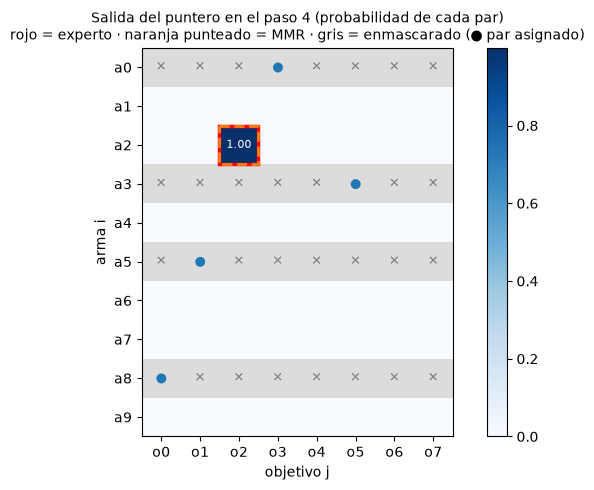

El modelo elige arma 2 -> obj 2 (p = 1.00) | experto: arma 2 -> obj 2 | MMR: arma 2 -> obj 2


In [23]:
with torch.no_grad():
    p_demo = model(torch.tensor(x_demo), return_probabilities=True)[0].numpy()
grid = p_demo[1:].reshape(N_WEAPONS, N_TARGETS)
masked = x_demo[1:, COL_MASK].reshape(N_WEAPONS, N_TARGETS) == 1
fig, ax = plt.subplots(figsize=(7.5, 5))
im = ax.imshow(np.ma.masked_where(masked, grid), cmap="Blues", vmin=0, vmax=grid.max())
ax.imshow(np.ma.masked_where(~masked, np.ones_like(grid)), cmap="Greys", vmin=0, vmax=3, alpha=0.6)
for i in range(N_WEAPONS):
    for j in range(N_TARGETS):
        if masked[i, j]:
            ax.text(j, i, "✕" if x_demo[1 + i * N_TARGETS + j, 5] == 0 else "●", ha="center", va="center",
                    color="gray" if x_demo[1 + i * N_TARGETS + j, 5] == 0 else "tab:blue", fontsize=9)
        elif grid[i, j] > 0.01:
            ax.text(j, i, f"{grid[i, j]:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if grid[i, j] > grid.max() / 2 else "black")
ei, ej = chosen_demo[1]
ax.add_patch(plt.Rectangle((ej - 0.5, ei - 0.5), 1, 1, fill=False, ec="red", lw=2.5))
mmr_r = int(np.argmax(np.where(x_demo[:, COL_MASK] == 1, -1, x_demo[:, 8])))
mi, mj = (mmr_r - 1) // N_TARGETS, (mmr_r - 1) % N_TARGETS
ax.add_patch(plt.Rectangle((mj - 0.5, mi - 0.5), 1, 1, fill=False, ec="tab:orange", lw=2, ls="--"))
ax.set_xticks(range(N_TARGETS)); ax.set_xticklabels([f"o{j}" for j in range(N_TARGETS)])
ax.set_yticks(range(N_WEAPONS)); ax.set_yticklabels([f"a{i}" for i in range(N_WEAPONS)])
ax.set_xlabel("objetivo j"); ax.set_ylabel("arma i")
ax.set_title("Salida del puntero en el paso 4 (probabilidad de cada par)\n"
             "rojo = experto · naranja punteado = MMR · gris = enmascarado (● par asignado)", fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.04); plt.tight_layout(); guardar(fig, "salida"); plt.show()
print(f"El modelo elige arma {int(np.argmax(p_demo) - 1) // N_TARGETS} -> obj {int(np.argmax(p_demo) - 1) % N_TARGETS} "
      f"(p = {p_demo.max():.2f}) | experto: arma {ei} -> obj {ej} | MMR: arma {mi} -> obj {mj}")

### Rollout en una instancia nueva

Modelo (atención): [0, 0, 4, 2, 6, 1, 3, 6, 5, 7] costo = 44.456
MMR:               [0, 0, 4, 7, 2, 1, 3, 6, 5, 4] costo = 47.233
Experto (ILS):     [0, 0, 4, 2, 7, 1, 3, 6, 5, 4] costo = 44.284


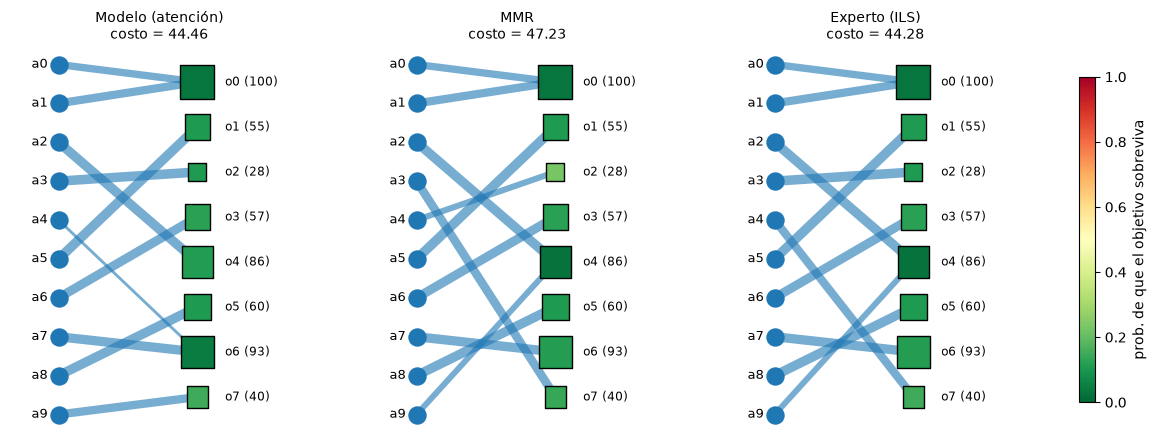

In [24]:
np.random.seed(45)
test_inst = WTAP_Instance.random()                        # misma instancia de ejemplo de la Tarea 4
sol_model, *_ = SingleAgentSolver(env, GreedyAgent(ModelEvalActions(model))).solve(WTAP_State(test_inst))
sol_mmr_t, *_ = mmr_agent.solve(WTAP_State(test_inst))
a_exp, c_exp = ils(test_inst, rng=np.random.default_rng(45))
print("Modelo (atención):", sol_model.assignment, f"costo = {sol_model.cost:.3f}")
print("MMR:              ", sol_mmr_t.assignment, f"costo = {sol_mmr_t.cost:.3f}")
print("Experto (ILS):    ", a_exp, f"costo = {c_exp:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (name, a) in zip(axes, [("Modelo (atención)", sol_model.assignment), ("MMR", sol_mmr_t.assignment),
                                ("Experto (ILS)", a_exp)]):
    sc = plot_partial(test_inst, a, ax=ax, title=f"{name}\ncosto = {cost_of(test_inst, a):.2f}")
fig.colorbar(sc, ax=axes, fraction=0.015, label="prob. de que el objetivo sobreviva")
guardar(fig, "rollout_ejemplo"); plt.show()

### Evaluación en las 50 instancias de prueba
Son **las mismas 50 instancias de la Tarea 4** (el costo medio del experto coincide), así que podemos comparar con la MLP de esa tarea, cuyo gap fue 4,42 %. Reportamos el gap porcentual respecto del experto, como en `print_gaps`.

In [25]:
GAP_MLP_T4 = 4.415       # gap promedio de la MLP de la Tarea 4 en estas mismas 50 instancias
test_insts = [inst for inst, _, _ in test_solved]

results = {
    "Modelo (atención)": rollout_costs(ModelEvalActions(model), test_insts),
    "MMR (heurística clásica)": rollout_costs(evalConstructiveActions, test_insts),
    "Experto (ILS)": test_expert,
}

def print_gaps(results, expert_costs, title):
    print(f"--- {title} ---")
    print(f"{'Método':<26} {'Costo medio':>11} {'Gap promedio':>13} {'Gap mediana':>12} {'% óptimo':>9}")
    for name, costs in results.items():
        g = gap(costs, expert_costs)
        print(f"{name:<26} {costs.mean():>11.3f} {g.mean():>12.2f}% {np.median(g):>11.2f}% "
              f"{100 * np.mean(g < 1e-6):>8.0f}%")
    print()

print_gaps(results, test_expert, "50 instancias de prueba, 10 armas × 8 objetivos")
print(f"Referencia: MLP de la Tarea 4 (orden fijo de armas) -> gap promedio {GAP_MLP_T4:.2f}%")
g_model, g_mmr = gap(results["Modelo (atención)"], test_expert), gap(results["MMR (heurística clásica)"], test_expert)
wins, ties = np.mean(g_model < g_mmr - 1e-9), np.mean(np.abs(g_model - g_mmr) <= 1e-9)
print(f"Modelo vs MMR: mejor en {100 * wins:.0f}% de las instancias, igual en {100 * ties:.0f}%, "
      f"peor en {100 * (1 - wins - ties):.0f}%")

--- 50 instancias de prueba, 10 armas × 8 objetivos ---
Método                     Costo medio  Gap promedio  Gap mediana  % óptimo
Modelo (atención)               47.697         2.97%        1.85%       30%
MMR (heurística clásica)        49.830         7.68%        7.75%        6%
Experto (ILS)                   46.263         0.00%        0.00%      100%

Referencia: MLP de la Tarea 4 (orden fijo de armas) -> gap promedio 4.42%
Modelo vs MMR: mejor en 72% de las instancias, igual en 20%, peor en 8%


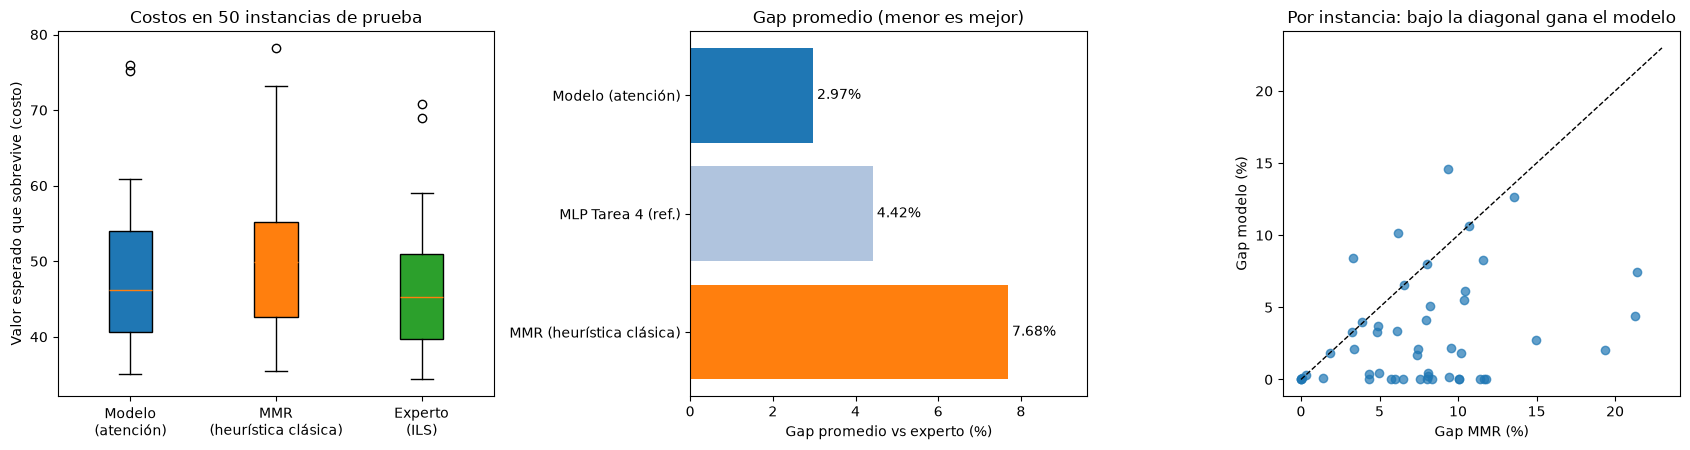

In [26]:
COLORES = {"Modelo (atención)": "tab:blue", "MMR (heurística clásica)": "tab:orange", "Experto (ILS)": "tab:green",
           "MLP Tarea 4 (ref.)": "lightsteelblue"}
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), gridspec_kw={"width_ratios": [1.1, 1, 1]})
names = list(results)
bp = axes[0].boxplot([results[n] for n in names], tick_labels=[n.replace(" (", "\n(") for n in names], patch_artist=True)
for patch, n in zip(bp["boxes"], names): patch.set_facecolor(COLORES[n])
axes[0].set_ylabel("Valor esperado que sobrevive (costo)"); axes[0].set_title("Costos en 50 instancias de prueba")

bars = {"Modelo (atención)": g_model.mean(), "MLP Tarea 4 (ref.)": GAP_MLP_T4, "MMR (heurística clásica)": g_mmr.mean()}
labels = list(bars)[::-1]
axes[1].barh(labels, [bars[n] for n in labels], color=[COLORES[n] for n in labels])
for i, n in enumerate(labels): axes[1].text(bars[n] + 0.1, i, f"{bars[n]:.2f}%", va="center")
axes[1].set_xlabel("Gap promedio vs experto (%)"); axes[1].set_title("Gap promedio (menor es mejor)")
axes[1].set_xlim(0, max(bars.values()) * 1.25)

lim = max(g_model.max(), g_mmr.max()) * 1.05 + 0.5
axes[2].scatter(g_mmr, g_model, color="tab:blue", alpha=0.7)
axes[2].plot([0, lim], [0, lim], "k--", lw=1)
axes[2].set_xlabel("Gap MMR (%)"); axes[2].set_ylabel("Gap modelo (%)")
axes[2].set_title("Por instancia: bajo la diagonal gana el modelo")
plt.tight_layout(); guardar(fig, "comparacion"); plt.show()

## 10. (Opcional) Generalización a instancias más grandes

El experimento que la MLP **no podía hacer**: el modelo se entrenó solo con instancias de 10 armas × 8 objetivos (81 filas). Como ningún peso depende de W ni de T, lo usamos sin cambios en instancias de **15×10** (151 filas) y **20×15** (301 filas), con 20 instancias nuevas de cada tamaño resueltas por el experto.

In [27]:
sizes = [(10, 8), (15, 10), (20, 15)]
gen = {}
for (W, T) in sizes:
    t0 = time.time()
    if (W, T) == (N_WEAPONS, N_TARGETS):
        insts, exp_c = test_insts, test_expert
        res = {k: v for k, v in results.items()}
    else:
        solved = solve_instances(W, T, 20, seed=3000 + W)
        insts, exp_c = [i for i, _, _ in solved], np.array([c for _, _, c in solved])
        res = {"Modelo (atención)": rollout_costs(ModelEvalActions(model), insts),
               "MMR (heurística clásica)": rollout_costs(evalConstructiveActions, insts),
               "Experto (ILS)": exp_c}
    gen[f"{W}×{T}"] = {n: gap(c, exp_c).mean() for n, c in res.items()}
    print_gaps(res, exp_c, f"{len(insts)} instancias de {W} armas × {T} objetivos ({1 + W * T} filas) — {time.time() - t0:.0f} s")

--- 50 instancias de 10 armas × 8 objetivos (81 filas) — 0 s ---
Método                     Costo medio  Gap promedio  Gap mediana  % óptimo
Modelo (atención)               47.697         2.97%        1.85%       30%
MMR (heurística clásica)        49.830         7.68%        7.75%        6%
Experto (ILS)                   46.263         0.00%        0.00%      100%



--- 20 instancias de 15 armas × 10 objetivos (151 filas) — 0 s ---
Método                     Costo medio  Gap promedio  Gap mediana  % óptimo
Modelo (atención)               36.989         4.89%        3.95%       10%
MMR (heurística clásica)        37.878         7.11%        6.36%        5%
Experto (ILS)                   35.356         0.00%        0.00%      100%



--- 20 instancias de 20 armas × 15 objetivos (301 filas) — 1 s ---
Método                     Costo medio  Gap promedio  Gap mediana  % óptimo
Modelo (atención)               67.692         3.90%        3.36%        0%
MMR (heurística clásica)        68.899         5.67%        5.96%        0%
Experto (ILS)                   65.148         0.00%        0.00%      100%



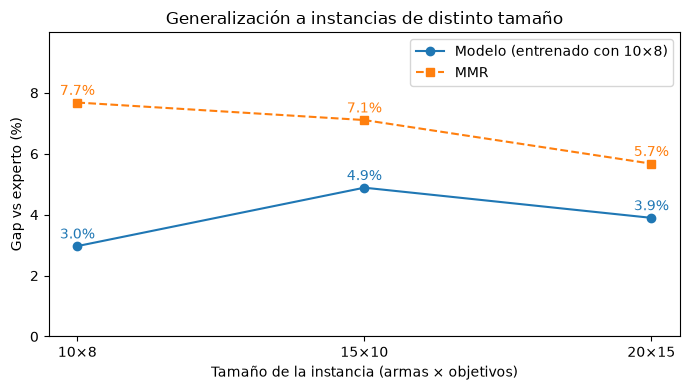

In [28]:
labels = list(gen)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(labels, [gen[l]["Modelo (atención)"] for l in labels], "o-", color="tab:blue", label="Modelo (entrenado con 10×8)")
ax.plot(labels, [gen[l]["MMR (heurística clásica)"] for l in labels], "s--", color="tab:orange", label="MMR")
for k, l in enumerate(labels):
    ax.text(k, gen[l]["Modelo (atención)"] + 0.25, f"{gen[l]['Modelo (atención)']:.1f}%", ha="center", color="tab:blue")
    ax.text(k, gen[l]["MMR (heurística clásica)"] + 0.25, f"{gen[l]['MMR (heurística clásica)']:.1f}%", ha="center", color="tab:orange")
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("Tamaño de la instancia (armas × objetivos)"); ax.set_ylabel("Gap vs experto (%)")
ax.set_title("Generalización a instancias de distinto tamaño"); ax.legend()
ax.set_ylim(0, max(max(v.values()) for v in gen.values()) * 1.3)
plt.tight_layout(); guardar(fig, "generalizacion"); plt.show()

## 11. Discusión

### ¿Qué aprendió el modelo?

- **Imitación.** El modelo elige el mismo par que el experto en **87,3 %** de las decisiones de validación; la regla "mayor ganancia" de MMR coincide solo en 79,9 %. Las decisiones más difíciles son las primeras (paso 0: 72 % con 80 acciones posibles), cuando aún quedan muchas armas y varias asignaciones son casi equivalentes; las últimas son casi perfectas. En todos los pasos (salvo el último, donde ambos aciertan siempre) el modelo supera a MMR: aprendió **cuándo no conviene** tomar el par de mayor ganancia inmediata.
- **Rollout.** Usado como política del mismo `GreedyAgent` que implementa MMR, logra un gap de **2,97 %** en las 50 instancias de prueba y encuentra la solución del experto en 30 % de ellas. MMR queda en 7,68 % y la MLP de la Tarea 4, en 4,42 % en estas mismas instancias. El modelo gana a MMR en 72 % de las instancias, empata en 20 % y pierde en el resto.
- **Las tres limitaciones de la Tarea 4 quedan resueltas:** todos los pares se evalúan con la misma función (pesos compartidos), ningún peso depende de W ni de T, y el agente decide también **qué arma** usar, igual que MMR. La mejora frente a la MLP combina dos cambios: la arquitectura comparte lo aprendido entre filas y la acción por pares da libertad al orden de construcción. No separamos experimentalmente cuánto aporta cada uno.

### Dropout y sobreajuste
El correo advierte que imitar trayectorias exactas tiende a sobreajustar, así que comparamos Dropout 0, 0,1 y 0,2. En nuestro caso la mejor configuración fue **sin Dropout** (gap de validación 3,35 % vs 3,51 % y 3,90 %), y las curvas muestran pérdidas de entrenamiento y validación casi iguales: con 60 000 muestras y solo 75 776 parámetros, compartidos entre las 81 filas, este modelo no llega a sobreajustar, así que el Dropout solo agrega ruido. La diferencia entre 0 y 0,1 es pequeña (100 instancias de validación), por lo que mantenemos el Dropout como hiperparámetro de la arquitectura. Si se reduce la cantidad de datos o se agranda el modelo, volvería a ser necesario.

### Generalización
Entrenado solo con instancias 10×8, el modelo se usa sin cambios en 15×10 (gap 4,89 % vs 7,11 % de MMR) y 20×15 (gap 3,90 % vs 5,67 %). El gap sube un poco respecto de 10×8, porque el modelo nunca vio estados con 150 o 300 acciones, pero **siempre queda bajo MMR**. Esto funciona porque las características están normalizadas por instancia y ninguna depende del índice de la fila. (En las instancias grandes, el experto es la mejor solución conocida del ILS, no un óptimo verificado.)

### Limitaciones y extensiones
- **Costo cuadrático:** con una fila por par hay $n = 1 + W\cdot T$ filas y la self-attention cuesta $O(n^2)$. Para instancias muy grandes convendría codificar armas y objetivos por separado ($W + T$ filas) y puntear sobre pares con una compatibilidad bilineal $h_i^\top M h_j$.
- **Regla de orden:** es una elección de diseño. Una alternativa es una pérdida multi-etiqueta que acepte como correcto cualquier par del experto aún pendiente.
- **Distribution shift:** un error temprano lleva al agente a estados que el experto nunca visitó. DAgger o el entrenamiento por refuerzo (el siguiente paso del curso) atacan este problema.
- **Arquitectura:** atención multi-cabeza, más capas o un *glimpse* antes del puntero, como sugiere el notebook del TSP.

In [29]:
summary = {
    "n_train_instances": len(train_solved), "n_train_samples": int(len(Y_train)),
    "n_val_samples": int(len(Y_val)), "n_test_instances": len(test_solved), "n_test_samples": int(len(Y_test)),
    "vec_len": VEC_LEN, "features": FEATURES, "n_rows": int(X_train.shape[1]),
    "final_model": best_name, "final_config": best["config"], "final_params": int(best["params"]),
    "val_acc_final": float(best["val_acc"]), "best_epoch_final": int(history["best_epoch"]),
    "epochs_final": len(history["val_loss"]),
    "experiments": {n: {"val_acc": float(e["val_acc"]), "val_loss": float(e["val_loss"]), "gap_val": float(e["gap"]),
                        "params": int(e["params"]), "config": e["config"]} for n, e in experiments.items()},
    "gap_mmr_val": float(gap_mmr_val),
    "acc_step": [float(a) for a in acc_step], "acc_mmr_step": [float(a) for a in acc_mmr_step],
    "test": {n: {"mean_cost": float(c.mean()), "mean_gap": float(gap(c, test_expert).mean()),
                 "pct_optimal": float(100 * np.mean(gap(c, test_expert) < 1e-6))} for n, c in results.items()},
    "gap_mlp_t4": GAP_MLP_T4,
    "model_vs_mmr": {"wins": float(wins), "ties": float(ties)},
    "generalization": {k: {n: float(v) for n, v in d.items()} for k, d in gen.items()},
    "demo": {"step": K_DEMO, "assignment": [int(v) for v in st_demo.assignment], "chosen": list(chosen_demo[1]),
             "row": int(row_demo), "mmr": [int(mi), int(mj)],
             "model": [int(np.argmax(p_demo) - 1) // N_TARGETS, int(np.argmax(p_demo) - 1) % N_TARGETS],
             "p_model": float(p_demo.max()), "n_actions": len(actions_demo),
             "expert_solution": sol_ils, "expert_cost": float(cost_ils),
             "steps": [{"k": k, "free": len(st.free_weapons), "n_actions": len(acts), "chosen": list(ch[1]),
                        "mmr": list(max(evalConstructiveActions(st, env), key=lambda e: e[1])[0][1])}
                       for k, (st, acts, ch) in enumerate(demo_steps)]},
}
with open("figuras_t5/resultados.json", "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False, default=int)
print(json.dumps(summary["test"], indent=2, ensure_ascii=False))

{
  "Modelo (atención)": {
    "mean_cost": 47.6968017214299,
    "mean_gap": 2.9677121395262445,
    "pct_optimal": 30.0
  },
  "MMR (heurística clásica)": {
    "mean_cost": 49.83016348193226,
    "mean_gap": 7.682223203939117,
    "pct_optimal": 6.0
  },
  "Experto (ILS)": {
    "mean_cost": 46.26281573773545,
    "mean_gap": 0.0,
    "pct_optimal": 100.0
  }
}
